# N13 — Safety Car Probability: EDA & Labeling

The goal of this notebook is to build the labeled dataset for the safety car probability
model (N14). We work at the level of **race laps**: one row per (race, lap_number),
aggregating the observable state of the field at that point in the race.

For each lap we determine whether a Safety Car or Virtual Safety Car deployment
occurred within the next 5 laps — defining the binary `sc_within_5_laps` label.

The output is a Parquet file with race-state features and a binary SC label,
ready for Random Forest training in N14.

> **Dataset note:** unlike the overtake dataset (~28k pairs), the SC dataset is
> significantly smaller — ~3,500 rows (58 races × ~60 laps). Class imbalance
> and validation strategy are designed accordingly.

**Data sources:**
- `session.laps` — lap times, tyre data, positions, retirements (2023–2025)
- `session.track_status` — timestamped track status changes at second-level resolution;
  used to derive yellow flag counts and escalation patterns per lap window
- `session.race_control_messages` — timestamped FIA messages (incidents, yellow sectors,
  SC/VSC announcements); captures the precursor signals that precede SC deployments
- `data/processed/circuit_clustering/` — circuit cluster assignments

**Exports:**
- EDA plots → `notebooks/strategy/sc_probability/outputs/`
- Labeled dataset → `data/processed/sc_labeled/`


---

## Step 0 - Setup and Imports 

In [18]:
# ── Step 0 — Setup ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")
import pathlib
import json
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Repo root ─────────────────────────────────────────────────────────────────
repo_root = pathlib.Path.cwd()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent

# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUTS    = repo_root / "notebooks" / "strategy" / "sc_probability" / "outputs"
PROCESSED  = repo_root / "data" / "processed" / "sc_labeled"
CACHE      = repo_root / "data" / "cache" / "fastf1"
CLUSTERING = repo_root / "data" / "processed" / "circuit_clustering"

OUTPUTS.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE))


In [19]:
print(f"Repo root  : {repo_root}")
print(f"Outputs    : {OUTPUTS}")
print(f"Processed  : {PROCESSED}")
print(f"Clustering : {CLUSTERING}")
print(f"FF1 cache  : {CACHE}")

Repo root  : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
Outputs    : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\sc_probability\outputs
Processed  : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\sc_labeled
Clustering : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\circuit_clustering
FF1 cache  : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\cache\fastf1


---

## Step 1 — Schedule & Circuit Clusters

Load the race calendar for 2023–2025 and attach the circuit cluster label to each
event. The cluster (0–3) encodes the circuit type (power, high-downforce, balanced,
street) and will be used as a categorical feature in N14.

**Circuit cluster source:** `data/processed/circuit_clustering/circuit_clusters_k4.parquet`
— produced in the circuit clustering notebook and reused across all strategy models.


In [20]:
# ── Step 1 — Schedule & circuit clusters ──────────────────────────────────────
SEASONS = [2023, 2024, 2025]


def load_circuit_clusters(clustering_path: pathlib.Path) -> dict:
    """Load GP_Name → Cluster mapping from the k4 parquet file."""
    df = pd.read_parquet(clustering_path / "circuit_clusters_k4.parquet")
    return dict(zip(df["GP_Name"], df["Cluster"]))


def resolve_cluster(location: str, cluster_map: dict) -> int:
    """Fuzzy-match a FastF1 Location string to a cluster id. Returns -1 if unknown."""
    for key, cluster in cluster_map.items():
        if key.lower() in location.lower() or location.lower() in key.lower():
            return cluster
    return -1


def load_schedule(seasons: list, cluster_map: dict) -> pd.DataFrame:
    """Fetch race calendars for each season, filter to Race rounds, attach cluster."""
    rows = []
    for year in seasons:
        sched = fastf1.get_event_schedule(year, include_testing=False)
        races = sched[
            sched["EventFormat"].isin(["conventional", "sprint_shootout", "sprint"]) &
            (sched["Session5"] == "Race")
        ].copy()
        races["year"] = year
        rows.append(races[["year", "RoundNumber", "EventName", "Location", "Country"]])
    schedule = pd.concat(rows, ignore_index=True)
    schedule["circuit_cluster"] = schedule["Location"].apply(
        lambda loc: resolve_cluster(loc, cluster_map)
    )
    return schedule


# ── Run ───────────────────────────────────────────────────────────────────────
cluster_map = load_circuit_clusters(CLUSTERING)
schedule    = load_schedule(SEASONS, cluster_map)

unknown = schedule[schedule["circuit_cluster"] == -1]
print(f"Circuit clusters loaded : {len(cluster_map)} circuits")
print(f"Schedule loaded         : {len(schedule)} races across {SEASONS}")
print(f"Unknown clusters        : {len(unknown)}")
if len(unknown):
    print(unknown[["year", "EventName", "Location"]].to_string(index=False))
print(f"\nCluster distribution:\n{schedule['circuit_cluster'].value_counts().sort_index()}")


Circuit clusters loaded : 25 circuits
Schedule loaded         : 58 races across [2023, 2024, 2025]
Unknown clusters        : 0

Cluster distribution:
circuit_cluster
0    15
1    19
2    10
3    14
Name: count, dtype: int64


---

## Step 2 — Load Race Laps, Track Status & Race Control Messages

For each of the 58 races (2023–2025) we load three data sources per session:

- **`session.laps`** — one row per driver per lap; aggregated to race-lap level for
  the base features (lap times, tyre life, retirements).
- **`session.track_status`** — timestamped DataFrame recording every track status
  change during the race at second-level resolution. Unlike the per-lap
  `TrackStatus` field on laps, this gives us the *exact moment* a yellow or SC
  was called, allowing us to count how many status changes occurred within each
  lap window.
- **`session.race_control_messages`** — timestamped FIA messages including incident
  reports, yellow flag sector notifications, and SC/VSC announcements. These are
  the observable precursor signals that precede most SC deployments by 1–2 laps.

`track_status` and `race_control_messages` are stored as per-race dicts keyed by
`"{year}_{round}"` and used in Step 3 to engineer the richer lap-window features.

### TrackStatus field

`TrackStatus` is a **concatenated string of single-digit FIA codes** — a lap that
crosses a status boundary carries both codes (e.g. `'21'` for yellow then clear,
`'46'` for SC entering VSC). The full code table:

| Code | Status | Race relevance |
|------|--------|----------------|
| `'1'` | Track clear — green flag | Normal racing |
| `'2'` | Yellow flag (local caution) | Incident in sector |
| `'4'` | **Safety Car deployed** | Full-course caution |
| `'5'` | Red flag — session stopped | Rare; aborts the race |
| `'6'` | **Virtual Safety Car** | Speed-delta caution |
| `'7'` | VSC ending (transition) | Brief before returning to green |

`most_severe_status` parses each character independently and returns the single
highest-severity code: `'4'` (SC) > `'6'` (VSC) > `'5'` (red) > `'7'` (VSC ending)
> `'2'` (yellow) > `'1'` (green).


In [21]:
# ── Step 2 — Load race laps + track_status + race_control_messages ────────────
STATUS_SEVERITY = {"1": 0, "2": 1, "7": 2, "5": 3, "6": 4, "4": 5}


def most_severe_status(statuses: pd.Series) -> str:
    """Return the highest-severity single-digit FIA code from a Series of
    concatenated TrackStatus strings (e.g. '12', '46')."""
    best_sev, best_code = -1, "1"
    for raw in statuses.dropna().astype(str):
        for ch in raw:
            sev = STATUS_SEVERITY.get(ch, -1)
            if sev > best_sev:
                best_sev, best_code = sev, ch
    return best_code


def compute_retirements(laps: pd.DataFrame) -> pd.Series:
    """Return a Series indexed by LapNumber with the cumulative count of drivers
    who have disappeared from the field up to and including that lap."""
    grp          = laps.groupby("LapNumber")
    drivers_each = grp["Driver"].apply(set)
    all_drivers  = set(laps["Driver"].unique())
    return drivers_each.index.to_series().apply(
        lambda n: len(all_drivers - set().union(*drivers_each[:n]))
    )


def aggregate_laps(laps: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-driver lap rows into one row per LapNumber."""
    laps = laps.copy()
    laps["TrackStatus"] = laps["TrackStatus"].astype(str)
    grp = laps.groupby("LapNumber")

    agg = grp.agg(
        lap_time_mean  = ("LapTime",     lambda x: x.dt.total_seconds().mean()),
        lap_time_std   = ("LapTime",     lambda x: x.dt.total_seconds().std()),
        lap_time_min   = ("LapTime",     lambda x: x.dt.total_seconds().min()),
        n_drivers      = ("Driver",      "count"),
        tyre_life_mean = ("TyreLife",    "mean"),
        tyre_life_max  = ("TyreLife",    "max"),
        track_status   = ("TrackStatus", most_severe_status),
    ).reset_index()

    agg["retirements"] = compute_retirements(laps).values

    if "Rainfall" in laps.columns:
        rain = grp["Rainfall"].agg(lambda x: int(x.mode()[0]) if not x.mode().empty else 0)
        agg["rainfall"] = agg["LapNumber"].map(rain).fillna(0).astype(int)
    else:
        agg["rainfall"] = 0

    return agg


def load_single_session(year: int, rnd: int, event_name: str, cluster: int
                        ) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame] | None:
    """Load one Race session and return (lap_agg, track_status_df, rcm_df).
    Returns None on failure."""
    try:
        session = fastf1.get_session(year, rnd, "R")
        session.load(laps=True, weather=True, telemetry=False, messages=True)
        laps = session.laps.copy()
        if laps.empty:
            return None

        lap_agg            = aggregate_laps(laps)
        lap_agg["race_id"] = f"{year}_{rnd}"
        lap_agg["year"]    = year
        lap_agg["round"]   = rnd
        lap_agg["event_name"]      = event_name
        lap_agg["circuit_cluster"] = cluster
        lap_agg["total_laps"]      = laps["LapNumber"].max()
        lap_agg["lap_pct"]         = lap_agg["LapNumber"] / lap_agg["total_laps"]

        try:
            ts = session.track_status.copy()
        except Exception:
            ts = pd.DataFrame(columns=["Time", "Status"])

        try:
            rcm = session.race_control_messages.copy()
        except Exception:
            rcm = pd.DataFrame(columns=["Time", "Category", "Message", "Flag", "Scope", "Sector"])

        return lap_agg, ts, rcm

    except Exception as e:
        print(f"  FAIL {year} R{rnd} {event_name}: {e}")
        return None


def load_all_sessions(schedule: pd.DataFrame) -> tuple[pd.DataFrame, dict, dict]:
    """Iterate over all races, load sessions, return aggregated lap table and
    per-race dicts for track_status and race_control_messages."""
    rows, ts_store, rcm_store, failed = [], {}, {}, []

    for _, race in schedule.iterrows():
        year, rnd  = int(race["year"]), int(race["RoundNumber"])
        event_name = race["EventName"]
        cluster    = int(race["circuit_cluster"])
        race_id    = f"{year}_{rnd}"

        result = load_single_session(year, rnd, event_name, cluster)
        if result is None:
            failed.append((year, rnd, event_name))
            continue

        lap_agg, ts, rcm = result
        rows.append(lap_agg)
        ts_store[race_id]  = ts
        rcm_store[race_id] = rcm

    raw = pd.concat(rows, ignore_index=True)
    return raw, ts_store, rcm_store, failed


# ── Run ───────────────────────────────────────────────────────────────────────
raw, ts_store, rcm_store, failed = load_all_sessions(schedule)

print(f"Loaded      : {len(raw['race_id'].unique())} races  |  {len(raw)} lap-rows")
print(f"Failed      : {len(failed)}")
print(f"ts_store    : {len(ts_store)} entries  |  sample cols: {list(next(iter(ts_store.values())).columns)}")
print(f"rcm_store   : {len(rcm_store)} entries  |  sample cols: {list(next(iter(rcm_store.values())).columns)}")
print(f"\ntrack_status distribution:\n{raw['track_status'].value_counts().sort_index()}")


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached d

Loaded      : 58 races  |  3506 lap-rows
Failed      : 0
ts_store    : 58 entries  |  sample cols: ['Time', 'Status', 'Message']
rcm_store   : 58 entries  |  sample cols: ['Time', 'Category', 'Message', 'Status', 'Flag', 'Scope', 'Sector', 'RacingNumber', 'Lap']

track_status distribution:
track_status
1    3133
2     140
4     173
5       2
6      58
Name: count, dtype: int64


**Step 2 results — 58 races loaded, 0 failures, 3,506 lap-rows.**

Track status breakdown across all laps:

| Status | Code | Count | % laps |
|--------|------|-------|--------|
| Green  | `1`  | 3,133 | 89.4%  |
| Yellow | `2`  |   140 |  4.0%  |
| SC     | `4`  |   173 |  4.9%  |
| VSC    | `6`  |    58 |  1.7%  |
| Red    | `5`  |     2 |  0.1%  |

SC + VSC combined: **231 caution laps (6.6%)** — this is the raw caution rate at lap
level, before the 5-lap forward window in Step 4 inflates the positive class.
The 140 yellow-flag laps are candidate precursors; whether they systematically precede
SC deployments is exactly what the EDA in Step 5 will confirm.

Two useful structural findings from the loaded dicts:
- `ts_store` carries a `Message` column alongside `Time`/`Status`, providing
  human-readable context for each status change (e.g. `"SAFETY CAR DEPLOYED"`).
- `rcm_store` includes a `Lap` column — direct integer join by lap number in Step 3,
  no timestamp interpolation needed.


---

## Step 3 — Feature Engineering

We enrich the base lap-level table with features derived from the two timestamped
sources loaded in Step 2. The goal is to capture the *observable race state* at
each lap — not just what is happening, but what has been building up in the laps
before.

**Lap-level features** (already in `raw`): `lap_time_mean`, `lap_time_std`,
`lap_time_min`, `n_drivers`, `tyre_life_mean`, `tyre_life_max`, `retirements`,
`rainfall`, `lap_pct`, `circuit_cluster`.

**From `raw["track_status"]`** (per-lap most-severe code):
- `yellow_count_prev3` — number of laps in the previous 3 with `track_status == '2'`;
  captures local incident escalation patterns before a potential SC.
- `laps_under_sc` — consecutive laps the SC has been active up to and including
  this lap; non-zero only while SC is deployed.
- `status_changed` — binary; did `track_status` change from the previous lap?
  Flags the exact laps where conditions shifted.

**From `rcm_store`** (race control messages, joined via `Lap` column):
- `had_incident_msg` — binary; at least one yellow flag (`Flag == "YELLOW"`),
  car event (`Category == "CarEvent"`), incident report (excluding track limits
  deletions), or safety car message was issued on this lap.
- `yellow_sectors_prev3` — count of sector-scope yellow flag messages in the
  previous 3 laps; sector yellows are the earliest observable precursor to SC.
- `flags_escalating` — binary; `had_incident_msg == 1` this lap AND `track_status`
  is `'4'` or `'6'` on the next lap. Computed for EDA purposes only —
  **excluded from model features** to avoid forward leakage.

All rolling/lag features are computed within each race (`groupby race_id`) to
prevent cross-race contamination.


In [22]:
# ── Step 3 — Feature Engineering ──────────────────────────────────────────────

def compute_track_status_features(grp: pd.DataFrame) -> pd.DataFrame:
    """Add track-status derived features to a single-race lap table.

    Features added (in-place on a copy):
    - yellow_count_prev3  : yellows in the 3 laps before this one
    - laps_under_sc       : consecutive SC-active laps up to and incl. this lap
    - status_changed      : did track_status change vs the previous lap?
    """
    grp = grp.copy()
    is_yellow = (grp["track_status"] == "2").astype(int)
    is_sc     = (grp["track_status"] == "4").astype(int)

    grp["yellow_count_prev3"] = (
        is_yellow.shift(1).rolling(3, min_periods=1).sum().fillna(0).astype(int)
    )

    streak, sc_streak = 0, []
    for s in is_sc:
        streak = streak + 1 if s else 0
        sc_streak.append(streak)
    grp["laps_under_sc"] = sc_streak

    grp["status_changed"] = (
        (grp["track_status"] != grp["track_status"].shift(1)).astype(int)
    )
    grp.loc[grp["LapNumber"] == grp["LapNumber"].min(), "status_changed"] = 0

    return grp


def build_incident_mask(rcm_lap: pd.DataFrame) -> pd.Series:
    """Return a boolean mask for RCM rows that represent genuine incident signals.

    Captures:
    - Yellow flag messages (Flag == "YELLOW")
    - Car events (Category == "CarEvent")
    - Incident messages, excluding track-limits deletions
    - Safety car messages
    """
    return (
        (rcm_lap["Flag"] == "YELLOW") |
        (rcm_lap["Category"] == "CarEvent") |
        (
            rcm_lap["Message"].str.upper().str.contains("INCIDENT", na=False) &
            ~rcm_lap["Message"].str.upper().str.contains("TRACK LIMITS", na=False)
        ) |
        rcm_lap["Message"].str.upper().str.contains("SAFETY CAR", na=False)
    )


def compute_rcm_features(grp: pd.DataFrame, rcm: pd.DataFrame) -> pd.DataFrame:
    """Add race-control-message derived features to a single-race lap table.

    Requires rcm to have a 'Lap' column (integer-joinable).

    Features added:
    - had_incident_msg      : binary; at least one incident signal on this lap
    - yellow_sectors_prev3  : sector-scope yellows in the 3 laps before this one
    - flags_escalating      : incident this lap AND SC/VSC next lap (EDA only — not for model)
    """
    grp = grp.copy()

    if rcm.empty or "Lap" not in rcm.columns:
        grp["had_incident_msg"]     = 0
        grp["yellow_sectors_prev3"] = 0
        grp["flags_escalating"]     = 0
        return grp

    rcm_lap = rcm.dropna(subset=["Lap"]).copy()
    rcm_lap["Lap"] = rcm_lap["Lap"].astype(int)

    # had_incident_msg
    incident_laps = set(rcm_lap[build_incident_mask(rcm_lap)]["Lap"])
    grp["had_incident_msg"] = grp["LapNumber"].astype(int).isin(incident_laps).astype(int)

    # yellow_sectors_prev3
    sector_yellow = rcm_lap[
        rcm_lap["Scope"].str.upper().str.contains("SECTOR", na=False) &
        (
            rcm_lap["Flag"].str.upper().str.contains("YELLOW", na=False) |
            rcm_lap["Message"].str.upper().str.contains("YELLOW", na=False)
        )
    ].groupby("Lap").size()
    grp["_sy"] = grp["LapNumber"].astype(int).map(sector_yellow).fillna(0)
    grp["yellow_sectors_prev3"] = (
        grp["_sy"].shift(1).rolling(3, min_periods=1).sum().fillna(0).astype(int)
    )
    grp = grp.drop(columns=["_sy"])

    # flags_escalating (EDA diagnostic — excluded from model features)
    grp["flags_escalating"] = (
        (grp["had_incident_msg"] == 1) &
        (grp["track_status"].shift(-1).isin(["4", "6"]))
    ).astype(int)

    return grp


def engineer_features(raw: pd.DataFrame, rcm_store: dict) -> pd.DataFrame:
    """Orchestrator: apply track-status and RCM features to every race in raw."""
    feat_rows = []
    for race_id, grp in raw.groupby("race_id"):
        grp = grp.sort_values("LapNumber")
        grp = compute_track_status_features(grp)
        grp = compute_rcm_features(grp, rcm_store.get(race_id, pd.DataFrame()))
        feat_rows.append(grp)
    return pd.concat(feat_rows, ignore_index=True)


# ── Run ───────────────────────────────────────────────────────────────────────
df = engineer_features(raw, rcm_store)

print(f"Shape: {df.shape}")
print(f"\nFeature counts:")
print(f"  yellow_count_prev3 > 0  : {(df['yellow_count_prev3'] > 0).sum()}")
print(f"  laps_under_sc > 0       : {(df['laps_under_sc'] > 0).sum()}")
print(f"  status_changed = 1      : {df['status_changed'].sum()}")
print(f"  had_incident_msg = 1    : {df['had_incident_msg'].sum()} ({df['had_incident_msg'].mean()*100:.1f}%)")
print(f"  yellow_sectors_prev3 > 0: {(df['yellow_sectors_prev3'] > 0).sum()}")
print(f"  flags_escalating = 1    : {df['flags_escalating'].sum()}")


Shape: (3506, 23)

Feature counts:
  yellow_count_prev3 > 0  : 264
  laps_under_sc > 0       : 173
  status_changed = 1      : 211
  had_incident_msg = 1    : 660 (18.8%)
  yellow_sectors_prev3 > 0: 417
  flags_escalating = 1    : 105


**Step 3 results — 3,506 rows, 23 features.**

| Feature | Count | % laps | Notes |
|---|---|---|---|
| `yellow_count_prev3 > 0` | 264 | 7.5% | laps preceded by at least one yellow |
| `laps_under_sc > 0` | 173 | 4.9% | matches Step 2 SC count exactly ✅ |
| `status_changed = 1` | 211 | 6.0% | lap-to-lap status transitions |
| `had_incident_msg = 1` | 660 | 18.8% | yellow flags, incidents, car events, SC messages |
| `yellow_sectors_prev3 > 0` | 417 | 11.9% | sector yellows in 3-lap window |
| `flags_escalating = 1` | 105 | 3.0% | EDA only — excluded from model |

18.8% of laps carry at least one incident signal — plausible for F1, roughly one
notable on-track event every 5–6 laps. The 105 `flags_escalating` laps confirm the
signal has real predictive content: an incident message followed by SC/VSC within
one lap in ~3% of all racing laps.


> **Note for the Multi-Agent System (v0.10.0):** `session.race_control_messages`
> surfaces the full stream of FIA timing data — incident reports with car numbers,
> sector yellow flags, track limit violations, penalty announcements, safety car
> deployments, and DRS enable/disable events. This is essentially the same
> information a race engineer monitors on their timing screen.
>
> In the multi-agent architecture, a dedicated **Race Control Monitor** sub-agent
> could subscribe to this stream in real-time and feed structured signals to the
> Strategy Agent — complementing the Radio Agent (driver comms) with official FIA
> messages. The two sources together (radio sentiment + race control facts) give
> the Strategy Agent a much richer picture of the current race situation than
> either source alone.


---

## Step 4 — Labeling

We define the binary target `sc_within_5_laps`: **1** if a Safety Car (`'4'`) or
Virtual Safety Car (`'6'`) is deployed within the next 5 laps, **0** otherwise.

The 5-lap horizon is a deliberate strategic choice — it corresponds to the window
in which a pit stop decision can realistically be influenced by an anticipated SC.
Pitting under SC saves ~10–15s in pit loss time; a team that can anticipate it
even 2–3 laps ahead gains a meaningful advantage.

**Labeling logic:** for each lap we look forward at the `track_status` of the
next 5 laps within the same race. If any of them is `'4'` or `'6'`, the label
is 1. Laps within the last 5 of the race are labeled 0 by construction (no
forward window available) — this is intentional and consistent with the
inference use case, where the model is only queried mid-race.

Laps where the race is *already* under SC or VSC (`track_status` in `{'4','6'}`)
are **excluded from the positive label logic** — the event has already occurred
and the model would never be queried in that state for a forward-looking decision.


In [23]:
# ── Step 4 — Labeling ─────────────────────────────────────────────────────────
WINDOW   = 5
SC_CODES = {"4", "6"}


def label_single_race(grp: pd.DataFrame, window: int, sc_codes: set) -> pd.DataFrame:
    """Assign sc_within_5_laps label to a single race's lap table.

    Rules:
    - -1  : lap is already under SC/VSC — will be dropped before training
    -  1  : at least one SC/VSC code appears in the next `window` laps
    -  0  : no SC/VSC in the forward window
    """
    grp = grp.copy().sort_values("LapNumber")
    statuses = grp["track_status"].values
    n        = len(statuses)

    labels = np.zeros(n, dtype=int)
    for i in range(n):
        if statuses[i] in sc_codes:
            labels[i] = -1
            continue
        future    = statuses[i + 1 : i + 1 + window]
        labels[i] = int(any(s in sc_codes for s in future))

    grp["sc_within_5_laps"] = labels
    return grp


def build_labeled_dataset(df: pd.DataFrame, window: int = 5) -> pd.DataFrame:
    """Apply labeling to all races and drop already-under-SC laps.

    Returns a clean DataFrame with sc_within_5_laps in {0, 1} only.
    """
    labeled_rows = [
        label_single_race(grp, window, SC_CODES)
        for _, grp in df.groupby("race_id")
    ]
    labeled = pd.concat(labeled_rows, ignore_index=True)

    already_sc = (labeled["sc_within_5_laps"] == -1).sum()
    labeled    = labeled[labeled["sc_within_5_laps"] != -1].copy()

    pos   = (labeled["sc_within_5_laps"] == 1).sum()
    neg   = (labeled["sc_within_5_laps"] == 0).sum()
    total = len(labeled)

    print(f"Total labeled rows  : {total}")
    print(f"Already-SC dropped  : {already_sc}")
    print(f"Positive (label=1)  : {pos} ({pos/total*100:.1f}%)")
    print(f"Negative (label=0)  : {neg} ({neg/total*100:.1f}%)")
    print(f"\nLabel by year:")
    print(
        labeled.groupby("year")["sc_within_5_laps"]
        .agg(["sum", "count", "mean"])
        .rename(columns={"sum": "positives", "count": "total", "mean": "rate"})
        .assign(rate=lambda x: (x["rate"] * 100).round(1))
    )

    return labeled


# ── Run ───────────────────────────────────────────────────────────────────────
labeled = build_labeled_dataset(df, window=WINDOW)


Total labeled rows  : 3275
Already-SC dropped  : 231
Positive (label=1)  : 183 (5.6%)
Negative (label=0)  : 3092 (94.4%)

Label by year:
      positives  total  rate
year                        
2023         84   1238   6.8
2024         31   1042   3.0
2025         68    995   6.8


**Step 4 results — 3,275 labeled rows, 5.6% positive rate.**

| | Count | % |
|---|---|---|
| Positive `sc_within_5_laps = 1` | 183 | 5.6% |
| Negative `sc_within_5_laps = 0` | 3,092 | 94.4% |
| Dropped (already under SC/VSC) | 231 | — |

The 5.6% positive rate is lower than the naive estimate from the raw caution rate
(6.6%) because SC and VSC periods span multiple consecutive laps — a typical SC
deployment lasts 3–8 laps, all of which are dropped as already-under-caution.
Only the ~5 laps *before* each deployment are tagged as positive. Across 58 races
there are roughly 30–35 distinct SC/VSC deployment events, yielding ~183 positive
laps total.

**Class imbalance: ~18:1** — more severe than the overtake dataset (~11:1).
N14 will need `class_weight='balanced'` or equivalent to handle this.

**Year breakdown:**
- 2023: 6.8% — typical season, several high-incident circuits
- 2024: 3.0% — notably clean season, fewer SC deployments
- 2025: 6.8% — back to normal incidence rate

The 2024 anomaly is worth keeping in mind for temporal validation in N14:
the train set (2023+2024) mixes two very different SC-rate seasons, which
may make the 2024 contribution under-representative of typical race conditions.


## Step 5 — EDA

Exploratory analysis of the labeled dataset across four angles:

1. **Class distribution** — overall imbalance and breakdown by year.
2. **Positive rate by circuit cluster** — whether circuit type correlates with
   SC probability; street circuits (cluster 3) are expected to show higher rates.
3. **Positive rate by race phase** — SC deployments are not uniformly distributed;
   the opening laps (high tyre deg, cold tyres) and mid-race tend to see more incidents.
4. **Feature correlation with the label** — point-biserial correlation for numeric
   features and mean-by-label for binary flags; identifies which engineered features
   carry the most predictive signal before N14.


In [24]:
# ── Step 5 — EDA plot functions ───────────────────────────────────────────────
COLORS_SC = {"pos": "#e74c3c", "neg": "#3498db", "neutral": "#7f8c8d"}


def plot_class_distribution(df: pd.DataFrame, save_path) -> None:
    """Bar chart of SC positive/negative counts and rates by year."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    counts = df["sc_within_5_laps"].value_counts().sort_index()
    axes[0].bar(["Negative (0)", "Positive (1)"], counts.values,
                color=[COLORS_SC["neg"], COLORS_SC["pos"]])
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 15, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)
    axes[0].set_title("Global class balance")
    axes[0].set_ylabel("Lap count")

    rates = df.groupby("year")["sc_within_5_laps"].mean() * 100
    axes[1].bar(rates.index.astype(str), rates.values, color=COLORS_SC["pos"], alpha=0.85)
    for i, (yr, v) in enumerate(rates.items()):
        axes[1].text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=10)
    axes[1].set_title("SC positive rate by year")
    axes[1].set_ylabel("SC within 5 laps (%)")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


def plot_sc_rate_by_cluster(df: pd.DataFrame, save_path) -> None:
    """Bar chart of SC positive rate per circuit cluster."""
    cluster_names = {0: "Power (0)", 1: "High-spd (1)", 2: "Balanced (2)", 3: "High-df (3)"}
    cluster_stats = (
        df.groupby("circuit_cluster")["sc_within_5_laps"]
        .agg(rate="mean", count="count")
        .reset_index()
    )
    overall = df["sc_within_5_laps"].mean() * 100

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(
        cluster_stats["circuit_cluster"].map(cluster_names),
        cluster_stats["rate"] * 100,
        color=COLORS_SC["pos"], alpha=0.85
    )
    ax.axhline(overall, color="gray", linestyle="--", linewidth=1,
               label=f"Overall {overall:.1f}%")
    for bar, (_, row) in zip(bars, cluster_stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f"n={int(row['count'])}", ha="center", fontsize=9)
    ax.set_title("SC positive rate by circuit cluster")
    ax.set_ylabel("SC within 5 laps (%)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


def plot_sc_rate_by_phase(df: pd.DataFrame, save_path) -> None:
    """Bar chart of SC positive rate across 10 equal race-phase bins."""
    tmp = df.copy()
    tmp["phase_bin"] = pd.cut(
        tmp["lap_pct"], bins=10,
        labels=[f"{i*10}–{(i+1)*10}%" for i in range(10)]
    )
    phase_rate = tmp.groupby("phase_bin", observed=True)["sc_within_5_laps"].mean() * 100
    overall = df["sc_within_5_laps"].mean() * 100

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(phase_rate)), phase_rate.values, color=COLORS_SC["neutral"], alpha=0.85)
    ax.axhline(overall, color="gray", linestyle="--", linewidth=1,
               label=f"Overall {overall:.1f}%")
    ax.set_xticks(range(len(phase_rate)))
    ax.set_xticklabels(phase_rate.index, rotation=40, ha="right", fontsize=9)
    ax.set_title("SC positive rate by race phase")
    ax.set_ylabel("SC within 5 laps (%)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


def plot_feature_correlations(df: pd.DataFrame, save_path) -> None:
    """Horizontal bar chart of point-biserial correlation of each feature with the label."""
    features = [
        "lap_time_std", "lap_time_mean", "lap_time_min",
        "tyre_life_mean", "retirements", "rainfall", "lap_pct",
        "yellow_count_prev3", "laps_under_sc", "status_changed",
        "had_incident_msg", "yellow_sectors_prev3",
    ]
    corrs = pd.Series({
        f: stats.pointbiserialr(df["sc_within_5_laps"], df[f].fillna(0))[0]
        for f in features
    }).sort_values()

    colors = [COLORS_SC["pos"] if v > 0 else COLORS_SC["neg"] for v in corrs.values]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(corrs.index, corrs.values, color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Point-biserial correlation with sc_within_5_laps")
    ax.set_title("Feature correlation vs SC label")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

    print("\nCorrelations (sorted descending):")
    print(corrs.sort_values(ascending=False).round(4).to_string())


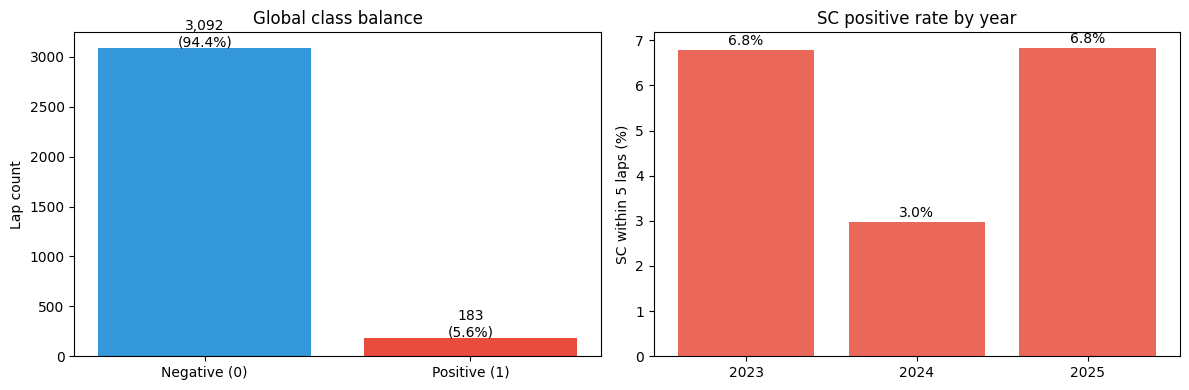

Saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\sc_probability\outputs\sc_class_distribution.png


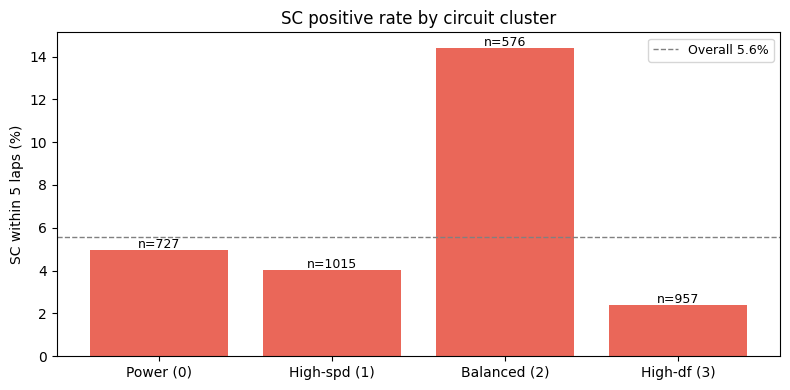

Saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\sc_probability\outputs\sc_rate_by_cluster.png


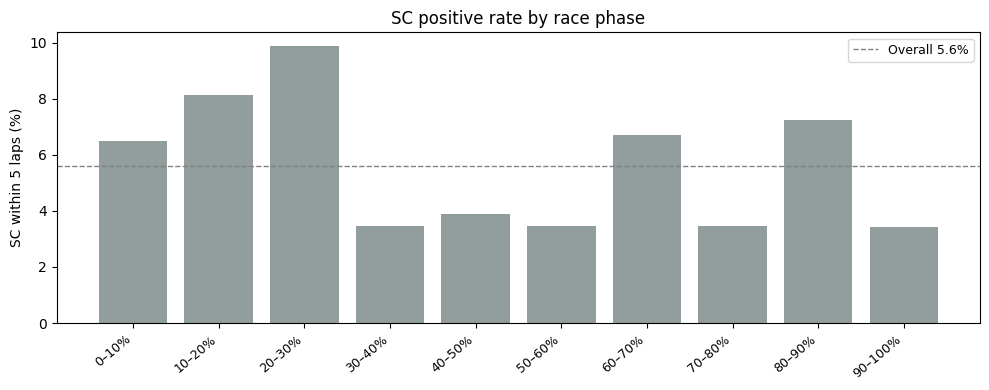

Saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\sc_probability\outputs\sc_rate_by_phase.png


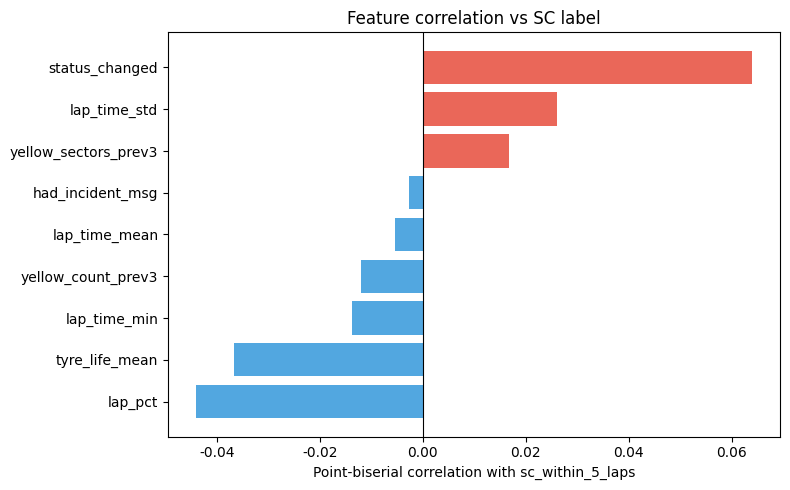

Saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\sc_probability\outputs\sc_feature_correlations.png

Correlations (sorted descending):
status_changed          0.0640
lap_time_std            0.0260
yellow_sectors_prev3    0.0168
had_incident_msg       -0.0026
lap_time_mean          -0.0054
yellow_count_prev3     -0.0120
lap_time_min           -0.0137
tyre_life_mean         -0.0368
lap_pct                -0.0441
retirements                NaN
rainfall                   NaN
laps_under_sc              NaN


In [25]:
# ── Step 5 — Run EDA plots ────────────────────────────────────────────────────
plot_class_distribution(labeled,   OUTPUTS / "sc_class_distribution.png")
plot_sc_rate_by_cluster(labeled,   OUTPUTS / "sc_rate_by_cluster.png")
plot_sc_rate_by_phase(labeled,     OUTPUTS / "sc_rate_by_phase.png")
plot_feature_correlations(labeled, OUTPUTS / "sc_feature_correlations.png")


**Step 5 results — EDA complete, 4 plots saved.**

### Class distribution

Confirmed **18:1 imbalance** (3,092 neg / 183 pos). The inter-season pattern holds:
2024 was anomalously clean (3.0%) against 2023 and 2025 (both 6.8%). This matters for
N14 — the training set will mix two very different SC-rate regimes.

### SC rate by circuit cluster

The most surprising finding of the EDA:

| Cluster | Rate | n |
|---------|------|---|
| Balanced (2) | **14.5%** | 576 |
| Power (0) | 5.0% | 727 |
| High-spd (1) | 4.0% | 1,015 |
| High-df (3) | 2.5% | 957 |

Cluster 2 ("balanced") is 2.6× the overall average. Counter-intuitive — street circuits
(cluster 3) were expected to lead. Mixed-characteristic circuits (Spa, Suzuka, Australia)
appear to accumulate more incidents. `circuit_cluster` will be a relevant feature in N14.

### SC rate by race phase

Clear bimodal pattern:
- **Peak at 20–30%**: ~10% — peak traffic phase post-lap 1, cold tyres, position battles
- **Secondary peak at 60–70% and 80–90%**: ~6.8–7.2% — second incident window as
  retirements accumulate and strategy gaps diverge
- **30–60%**: minimum (~3.5–4%), settled racing with established gaps

### Feature correlations with the label

All correlations are weak (max 0.064) — expected given strong imbalance and dispersed signal:

- `status_changed` (0.064) — strongest linear predictor; a lap where track status
  just changed is the most direct observable precursor of an SC deployment
- `lap_time_std` (0.026) and `yellow_sectors_prev3` (0.017) — field spread and sector
  yellows carry a small but consistent positive signal
- `had_incident_msg` (-0.003) — near zero. May still contribute via non-linear
  interactions in LightGBM, but has no standalone linear predictive power
- `retirements`, `rainfall`, `laps_under_sc` → NaN — near-zero variance; worth
  investigating before including in N14

> Weak correlations are not a blocker: LightGBM captures feature interactions
> that point-biserial misses entirely. The real signal likely lives in combinations
> such as `status_changed=1 AND yellow_sectors_prev3>0 AND lap_pct<0.3`.


---

## Step 6 — Export

Export the labeled dataset to Parquet for use in N14. A JSON sidecar records
the key labeling statistics for reproducibility.

**Output:** `data/processed/sc_labeled/sc_labeled_2023_2025.parquet`


In [26]:
# ── Step 6 — Export ────────────────────────────────────────────────────────────

EXPORT_FILE = PROCESSED / "sc_labeled_2023_2025.parquet"
STATS_FILE  = PROCESSED / "labeling_stats.json"

MODEL_FEATURES = [
    "lap_time_mean", "lap_time_std", "lap_time_min",
    "n_drivers", "tyre_life_mean", "tyre_life_max",
    "retirements", "rainfall", "lap_pct", "circuit_cluster",
    "yellow_count_prev3", "laps_under_sc", "status_changed",
    "had_incident_msg", "yellow_sectors_prev3",
]


def export_labeled_dataset(labeled: pd.DataFrame, export_file, stats_file) -> None:
    """Save labeled dataset to Parquet and write a JSON stats sidecar."""
    labeled.to_parquet(export_file, index=False)

    pos   = int((labeled["sc_within_5_laps"] == 1).sum())
    neg   = int((labeled["sc_within_5_laps"] == 0).sum())
    total = len(labeled)

    stats = {
        "export_file"    : str(export_file),
        "total_rows"     : total,
        "positive_rows"  : pos,
        "negative_rows"  : neg,
        "positive_rate"  : round(pos / total, 4),
        "seasons"        : sorted(labeled["year"].unique().tolist()),
        "races"          : int(labeled["race_id"].nunique()),
        "label_window"   : WINDOW,
        "sc_codes"       : sorted(SC_CODES),
        "model_features" : MODEL_FEATURES,
    }

    with open(stats_file, "w") as f:
        json.dump(stats, f, indent=2)

    print(f"Saved parquet → {export_file}")
    print(f"Saved stats   → {stats_file}")
    print(f"\nRows      : {total:,}  ({pos} pos / {neg} neg)")
    print(f"Pos rate  : {pos/total*100:.1f}%")
    print(f"Seasons   : {stats['seasons']}")
    print(f"Races     : {stats['races']}")
    print(f"Features  : {len(MODEL_FEATURES)}")


# ── Run ────────────────────────────────────────────────────────────────────────
export_labeled_dataset(labeled, EXPORT_FILE, STATS_FILE)


Saved parquet → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\sc_labeled\sc_labeled_2023_2025.parquet
Saved stats   → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\sc_labeled\labeling_stats.json

Rows      : 3,275  (183 pos / 3092 neg)
Pos rate  : 5.6%
Seasons   : [2023, 2024, 2025]
Races     : 58
Features  : 15


Labeled dataset saved to `data/processed/sc_labeled/sc_labeled_2023_2025.parquet`
— 3,275 rows, 15 model features, 5.6% positive rate across 58 races (2023–2025).

---

## Summary

N13 builds the labeled dataset for the Safety Car probability model.

Starting from FastF1 lap data, track status changes, and race control messages
across **58 races (2023–2025)**, the notebook produces a race-lap level dataset
with 15 engineered features and a binary label: `sc_within_5_laps`.

**Key numbers:**
- 3,275 labeled laps (231 dropped — already under SC/VSC)
- 5.6% positive rate (~18:1 class imbalance)
- 15 model features covering lap pace, tyre state, track status history, and incident signals

**Main EDA findings:**
- Balanced circuits (cluster 2) show 14.5% SC rate — 2.6× the overall average
- SC deployments concentrate in the first 30% of the race and resurge at 60–90%
- `status_changed` and `lap_time_std` are the strongest linear predictors; most
  signal is non-linear and will be captured by the tree-based model in N14
- 2024 was anomalously clean (3.0% vs 6.8% for 2023 and 2025)

**Exports:**
- `data/processed/sc_labeled/sc_labeled_2023_2025.parquet`
- `data/processed/sc_labeled/labeling_stats.json`

---

**Next → N14:** LightGBM classifier with Platt calibration, trained on 2023+2024
and tested on 2025. Output: `P(SC within N laps)` for use in the Strategy Agent's
window simulation.
